Ciscenje teksta...
Originalna dimenzija: (2000, 15000)
Redukovana dimenzija (SVD): (2000, 50)

--- PROŠIRENI REZULTATI EVALUACIJE ---
    Algoritam  Silhouette  Davies-Bouldin  Calinski-Harabasz       ARI
       KMeans    0.067595        3.830880          71.237240  0.003979
    MiniBatch    0.051692        4.379520          55.305841  0.007543
Agglomerative    0.050824        2.648321          62.786608 -0.000169
     Spectral    0.053580        3.010237          59.153613  0.000545
       DBSCAN    0.668671        0.443278          41.184413 -0.001716


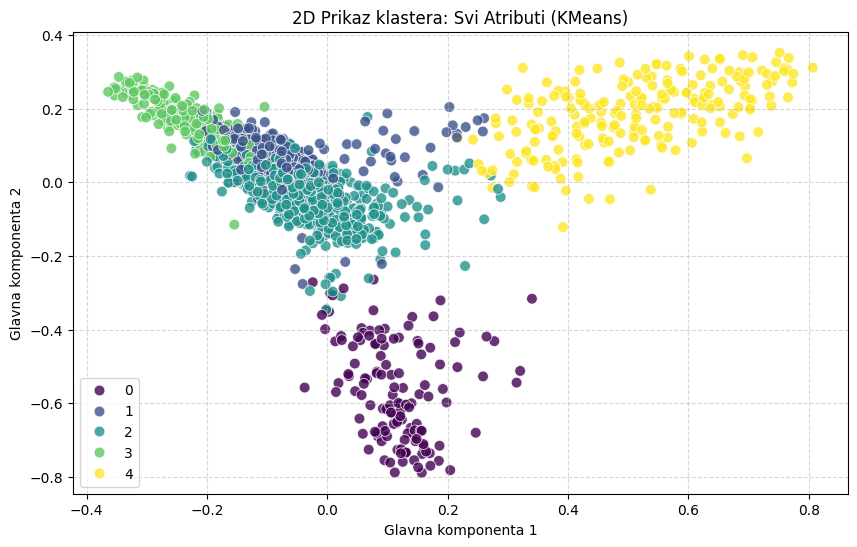

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD  
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer

def clean_text(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'<.*?>', '', text) # Uklanjanje HTML tagova
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Uklanjanje URL-ova
    text = text.translate(str.maketrans('', '', string.punctuation)) # Uklanjanje interpunkcije
    text = re.sub(r'\s+', ' ', text).strip() # Uklanjanje suvisnih razmaka
    return text

# Ucitavanje i priprema uzorka 
df = pd.read_csv("Reviews_sample_balanced.csv").dropna(subset=['Text']).sample(2000, random_state=42)
df = df.sample(n=2000, random_state=42).reset_index(drop=True)

print("Ciscenje teksta...")
df['Cleaned_Text'] = df['Text'].apply(clean_text)

# Vektorizacija teksta
tfidf = TfidfVectorizer(max_features=15000, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['Cleaned_Text'])

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

scaler = Normalizer()
X = scaler.fit_transform(X_svd)

print(f"Originalna dimenzija: {X_tfidf.shape}")
print(f"Redukovana dimenzija (SVD): {X.shape}")

def get_metrics(X, labels, true_labels, name):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters < 2:
        return [name, 0, 0, 0, 0]
    
    # Maskiranje suma za DBSCAN
    mask = labels != -1
    if not any(mask): return [name, 0, 0, 0, 0]

    s_score = silhouette_score(X[mask], labels[mask])
    db_index = davies_bouldin_score(X[mask], labels[mask])
    ch_index = calinski_harabasz_score(X[mask], labels[mask])
    # ARI poredi klastere sa Sentiment kolonom
    ari = adjusted_rand_score(true_labels[mask], labels[mask])
    
    return [name, s_score, db_index, ch_index, ari]


true_sent = df['Sentiment']
all_results = []

# KMeans
km = KMeans(n_clusters=5, random_state=42, n_init=10)
all_results.append(get_metrics(X, km.fit_predict(X), true_sent, "KMeans"))

# MiniBatch
mb = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=100, n_init=10)
all_results.append(get_metrics(X, mb.fit_predict(X), true_sent, "MiniBatch"))

# Agglomerative
agg = AgglomerativeClustering(n_clusters=5)
all_results.append(get_metrics(X, agg.fit_predict(X), true_sent, "Agglomerative"))

# Spectral
spec = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
all_results.append(get_metrics(X, spec.fit_predict(X), true_sent, "Spectral"))

# DBSCAN
db = DBSCAN(eps=0.4, min_samples=3)
all_results.append(get_metrics(X, db.fit_predict(X), true_sent, "DBSCAN"))

# --- 6) PRIKAZ REZULTATA ---
df_res = pd.DataFrame(all_results, columns=['Algoritam', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'ARI'])

print("\n--- PROŠIRENI REZULTATI EVALUACIJE ---")
print(df_res.to_string(index=False))

# PCA Vizuelizacija
pca_2d = PCA(n_components=2)
coords = pca_2d.fit_transform(X)

plt.figure(figsize=(10,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=km.labels_, palette='viridis', s=60, alpha=0.8)
plt.title('2D Prikaz klastera: Svi Atributi (KMeans)')
plt.xlabel('Glavna komponenta 1')
plt.ylabel('Glavna komponenta 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [17]:
df_res.to_csv("rezultati_svd.csv", index=False)

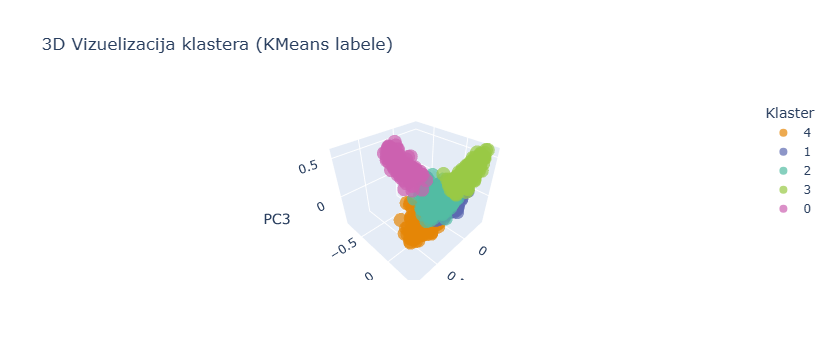

In [18]:
import plotly.express as px
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X)

df_3d = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Klaster'] = km.labels_.astype(str) 
df_3d['Text_Snippet'] = df['Text'].str[:50] 

fig = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3',
    color='Klaster',
    title='3D Vizuelizacija klastera (KMeans labele)',
    hover_data=['Text_Snippet'],
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Vivid
)
fig.show()